# Decodificación de Viterbi y Diagrama de Trellis

Este notebook replica el proceso de un codificador convolucional y un decodificador de Viterbi basado en una máquina de estados de Tasa 1/2 y memoria $K=3$ (4 estados posibles).

## 1. Conceptos Clave

* **Códigos Convolucionales:** A diferencia de los códigos de bloque, los códigos convolucionales procesan los datos en un flujo continuo. La salida depende no solo del bit de entrada actual, sino de los bits anteriores (memoria). Actúan como una máquina de estados finitos.
* **Máquina de Estados (State Machine):** Representa todas las combinaciones posibles de la memoria del codificador. En este ejemplo tenemos 4 estados representados por los 2 bits anteriores: `00`, `10`, `01`, `11`.
* **Diagrama de Trellis:** Es la expansión visual de la máquina de estados a lo largo del tiempo. Nos permite ver gráficamente cómo cambian los estados con cada bit entrante, mostrando todos los caminos posibles de la señal.
* **Métrica de Rama (Branch Metric):** En este caso, utilizaremos la **Distancia de Hamming**, que cuenta el número de bits que difieren entre el símbolo recibido y el símbolo esperado de una rama en el Trellis.
* **Algoritmo de Viterbi:** Es un algoritmo de programación dinámica utilizado para "rastrear" el diagrama de Trellis. Descarta continuamente los caminos menos probables y mantiene caminos "supervivientes" para encontrar la secuencia original de bits que tiene el costo acumulado más bajo (Métrica de Ruta).

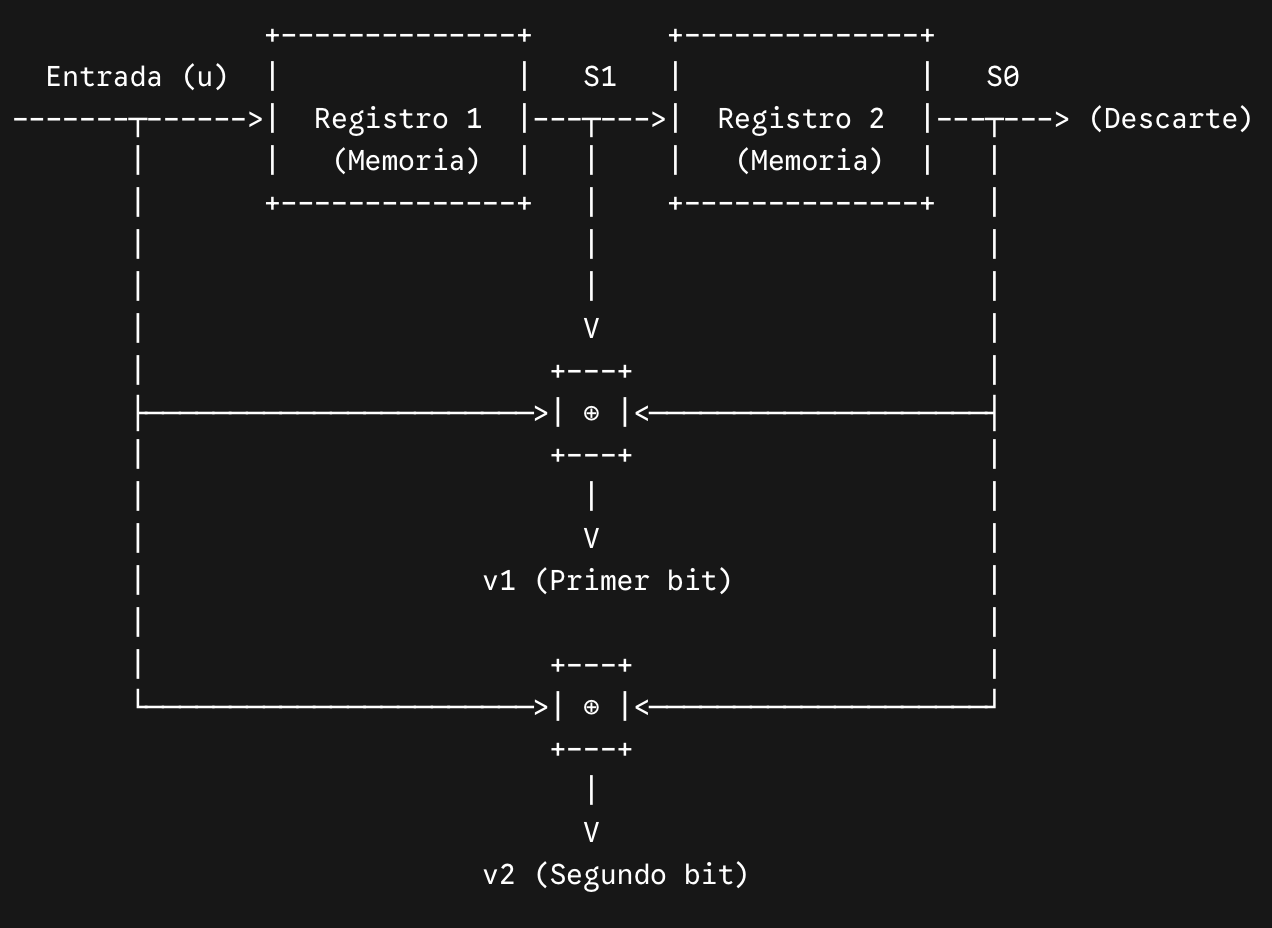

## Diagrama de Trellis (Transiciones de Estado)

El diagrama de Trellis es la representación del codificador desenrollado en el tiempo. Por cada bit que ingresa (instante $t$), el sistema hace una transición hacia un nuevo estado (instante $t+1$) y genera 2 bits de salida.

A continuación se muestra el bloque de construcción básico del Trellis.

### Representación Visual (Etapa única $t \rightarrow t+1$)
*Leyenda de las flechas: `[Bit de Entrada] / [Bits de Salida]`*

```text
Estado Actual (t)                           Siguiente Estado (t+1)

                      0 / 00
     [ 00 ] ──────────────────────────────> [ 00 ]
            \
             \        1 / 11
              \───────────────────────────> [ 10 ]


                      0 / 10
     [ 10 ] ──────────────────────────────> [ 01 ]
            \
             \        1 / 01
              \───────────────────────────> [ 11 ]


                      0 / 11
     [ 01 ] ──────────────────────────────> [ 00 ]
            \
             \        1 / 00
              \───────────────────────────> [ 10 ]


                      0 / 01
     [ 11 ] ──────────────────────────────> [ 01 ]
            \
             \        1 / 10
              \───────────────────────────> [ 11 ]

In [ ]:
# Diccionario del Trellis (Máquina de Estados)
# Estructura: trellis[estado_actual][bit_entrada] = (siguiente_estado, bits_salida)

trellis = {
    '00': {'0': ('00', '00'), '1': ('10', '11')},
    '10': {'0': ('01', '10'), '1': ('11', '01')},
    '01': {'0': ('00', '11'), '1': ('10', '00')},
    '11': {'0': ('01', '01'), '1': ('11', '10')}
}

print("Máquina de estados cargada correctamente.")

Máquina de estados cargada correctamente.


## 2. Codificador Convolucional

A continuación, implementamos una función que simula la transmisión de datos. Tomará una cadena de bits (ej. `"1011"`), iniciará en el estado `00`, y recorrerá el Trellis generando las salidas de 2 bits por cada bit de entrada.

In [ ]:
def codificador_convolucional(mensaje_bits, maquina_estados):
    estado_actual = '00'
    mensaje_codificado = ""

    for bit in mensaje_bits:
        siguiente_estado, salida = maquina_estados[estado_actual][bit]
        mensaje_codificado += salida
        estado_actual = siguiente_estado

    return mensaje_codificado

# Probamos el codificador con un mensaje
mensaje_original = "101100"
codigo_transmitido = codificador_convolucional(mensaje_original, trellis)

print(f"Mensaje Original:   {mensaje_original}")
print(f"Código Transmitido: {codigo_transmitido}")

Mensaje Original:   101100
Código Transmitido: 111000010111


## 3. El Decodificador de Viterbi

Aquí está la magia matemática explicada en el video. El algoritmo toma los bits recibidos (incluso si tienen ruido) agrupándolos de 2 en 2, y hace lo siguiente:
1. Calcula la **Distancia de Hamming** para las posibles transiciones desde los estados activos.
2. Acumula el costo en las **Métricas de Ruta** (Path Metrics).
3. Sobrescribe los caminos, guardando solo el camino superviviente (el de menor error) hacia cada nuevo estado.
4. Al final, escoge el estado con el menor error y nos devuelve la secuencia original.

In [ ]:
def decodificador_viterbi(bits_recibidos, maquina_estados):
    # metricas_ruta[estado] = (costo_acumulado, camino_de_bits)
    # Comenzamos desde el estado '00' con costo 0; los demás en infinito
    metricas_ruta = {
        '00': (0, ""), '10': (float('inf'), ""),
        '01': (float('inf'), ""), '11': (float('inf'), "")
    }

    # Función auxiliar: Distancia de Hamming
    def distancia_hamming(s1, s2):
        return sum(c1 != c2 for c1, c2 in zip(s1, s2))

    # Procesamos los bits recibidos de 2 en 2
    for i in range(0, len(bits_recibidos), 2):
        chunk = bits_recibidos[i:i+2]
        nuevas_metricas = {estado: (float('inf'), "") for estado in metricas_ruta}

        for estado_actual, (costo_actual, camino) in metricas_ruta.items():
            if costo_actual == float('inf'):
                continue

            # Evaluamos transiciones si el bit de entrada es '0' o '1'
            for bit_entrada, (siguiente_estado, salida_esperada) in maquina_estados[estado_actual].items():

                # 1. Calcular Métrica de Rama (Branch Metric)
                metrica_rama = distancia_hamming(chunk, salida_esperada)
                nuevo_costo = costo_actual + metrica_rama

                # 2. Actualizar la Métrica de Ruta (Path Metric) si es el mejor camino
                if nuevo_costo < nuevas_metricas[siguiente_estado][0]:
                    nuevas_metricas[siguiente_estado] = (nuevo_costo, camino + bit_entrada)

        metricas_ruta = nuevas_metricas

    # Extraemos el estado que terminó con el menor número de errores (menor costo)
    mejor_estado_final = min(metricas_ruta, key=lambda estado: metricas_ruta[estado][0])
    costo_final, secuencia_decodificada = metricas_ruta[mejor_estado_final]

    return secuencia_decodificada, costo_final

## 4. Simulando Ruido y Corrigiendo Errores

Vamos a tomar el código que generamos en el paso 2, le introduciremos un error intencional (como si el canal de transmisión tuviera ruido) y comprobaremos si el diagrama de Trellis usando Viterbi logra corregirlo.

In [ ]:
print(f"Código transmitido intacto: {codigo_transmitido}")

# Simulamos ruido: Alteramos intencionalmente el primer y quinto bit recibido
lista_recibida = list(codigo_transmitido)
lista_recibida[0] = '0' if lista_recibida[0] == '1' else '1'
lista_recibida[4] = '0' if lista_recibida[4] == '1' else '1'
codigo_con_ruido = "".join(lista_recibida)

print(f"Código recibido (c/ruido):  {codigo_con_ruido}")

# Pasamos el código con ruido por el decodificador de Viterbi
mensaje_recuperado, costo = decodificador_viterbi(codigo_con_ruido, trellis)

print("-" * 30)
print(f"Mensaje Original:    {mensaje_original}")
print(f"Mensaje Recuperado:  {mensaje_recuperado}")
print(f"Errores corregidos:  {costo} (Distancia de Hamming acumulada)")

if mensaje_original == mensaje_recuperado:
    print("¡El algoritmo de Viterbi corrigió el ruido exitosamente!")
else:
    print("El ruido fue excesivo y superó la capacidad de corrección.")

Código transmitido intacto: 111000010111
Código recibido (c/ruido):  011010010111
------------------------------
Mensaje Original:    101100
Mensaje Recuperado:  101100
Errores corregidos:  2 (Distancia de Hamming acumulada)
¡El algoritmo de Viterbi corrigió el ruido exitosamente!
